# Lesson 138 · E-commerce: what does Amazon churn actually mean?

Student lab · PROVIDED: inspect. TODO: implement. CHECK: run unchanged. EXIT: defend. Default execution checks real labels, re-scores 761,677 recency predictions and 3,808,385 neural predictions and runs a synthetic neural fixture. Fresh full training is separately gated.

<!-- course-portable:start -->
### Follow the computation

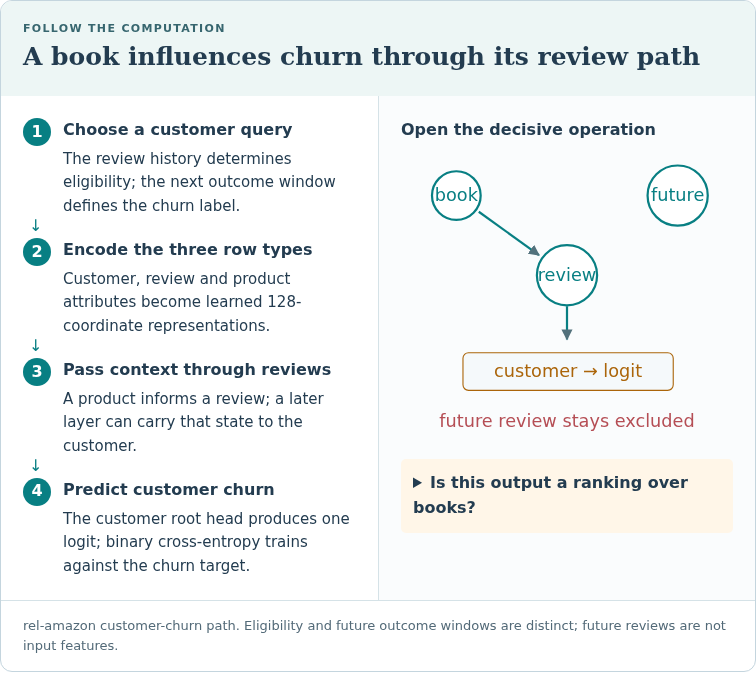

rel-amazon customer-churn path. Eligibility and future outcome windows are distinct; future reviews are not input features.

**Trace question:** Is this output a ranking over books?

**Trace answer:** No. It is one churn prediction for the queried customer. Books supply relational context through review rows.
<!-- course-portable:end -->

In [ ]:
# PROVIDED: portable defaults; full training is OFF.
import importlib.util,subprocess,sys
for module,package in [('numpy','numpy'),('pandas','pandas'),('torch','torch'),('torch_frame','pytorch-frame==0.3.0'),('torch_geometric','torch-geometric'),('relbench','relbench==1.1.0')]:
    if importlib.util.find_spec(module) is None:subprocess.check_call([sys.executable,'-m','pip','install','-q',package])
import numpy as np, pandas as pd, json, hashlib, base64, gzip, io
from pathlib import Path
RUN_FULL_REPRODUCTION=False


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Reading guide">
<p class="sequence-eyebrow">From diagnosis to the meaning of a label</p>
<p><strong>Reading route.</strong> Build one eligible query → trace book-to-customer information → interpret the ranking → inspect reproduction evidence.</p>
<details><summary>Quick prerequisite reminder</summary><p>A graph node represents a database row. A message is a numerical contribution from a linked row. Two layers allow information to cross two edges. A positive label is the outcome coded as 1; here it means no future review, not a recorded purchase cancellation.</p></details>
</aside>
<!-- sequence-review:end -->

<p class="stream-lead">Before predicting whether a customer will leave, establish what the database can actually observe.</p>

**Your win:** defend an Amazon churn prediction from its eligible customer and cutoff, through historical review messages, to a correctly interpreted ranking score.

[Student notebook](https://avistian.github.io/relational/labs/0138-ecommerce-amazon.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0138-ecommerce-amazon.html) · [Reference card](https://avistian.github.io/relational/reference/ecommerce-amazon.html) · [Reproduction protocol](https://avistian.github.io/relational/labs/l138-reproduction.md)



## 1 · A new domain changes the meaning of the question

[Lesson 137](https://avistian.github.io/relational/lessons/0137-error-analysis-reg.html) showed how to locate a model's errors. It left another question unresolved: does the target measure the real-world outcome we care about? Moving from race results to an online store makes this distinction concrete.





A **query** is a customer ID and a date at which we make a prediction. A **target** is the outcome observed after that date. RelBench's Amazon task calls its target *churn*: no recorded product review during the next 91 days. A customer is eligible only if they reviewed a product during the preceding 91 days. The task comes from an Amazon Books review dataset, not a complete purchase ledger. [Released task SQL](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/tasks/amazon.py) · [Dataset construction](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/datasets/amazon.py)

> **In plain terms.** The label answers “Will this recent reviewer stop reviewing for a while?” It cannot establish “Will this customer stop buying?”

Source construction also filters out products without parsed prices. This curated Books cohort is not a random sample of all Amazon customers.

That difference changes how we use a prediction. A review reminder and a purchase-retention campaign are different interventions. A high ranking score on review absence does not establish either intervention's effect.

**Primary reading:** [RelBench v1 §4, §5.1, Table 6 and Appendix B](https://arxiv.org/html/2407.20060v1). Read the named `rel-amazon/user-churn` row alongside its task definition before interpreting the score.



## 2 · Build the question before building the model

Let **t** be the query cutoff and **H = 91 days** the horizon. The recent window is **(t − H, t]**. Parentheses mean the endpoint is excluded; a square bracket means it is included. A customer belongs to the task only if at least one review falls inside that recent window. The future window is **(t, t + H]**. The churn label equals 1 when this future window contains no review, and 0 otherwise.

**Worked example.** At cutoff day 0, customer A has reviews on days −12 and +91. A is eligible because −12 is in (−91, 0]. A's label is 0 because +91 is in (0, 91]. Customer B has only a review on day −91. B is ineligible; assigning B label 1 would invent a query outside the task population.

<figure class="stream-figure" tabindex="0">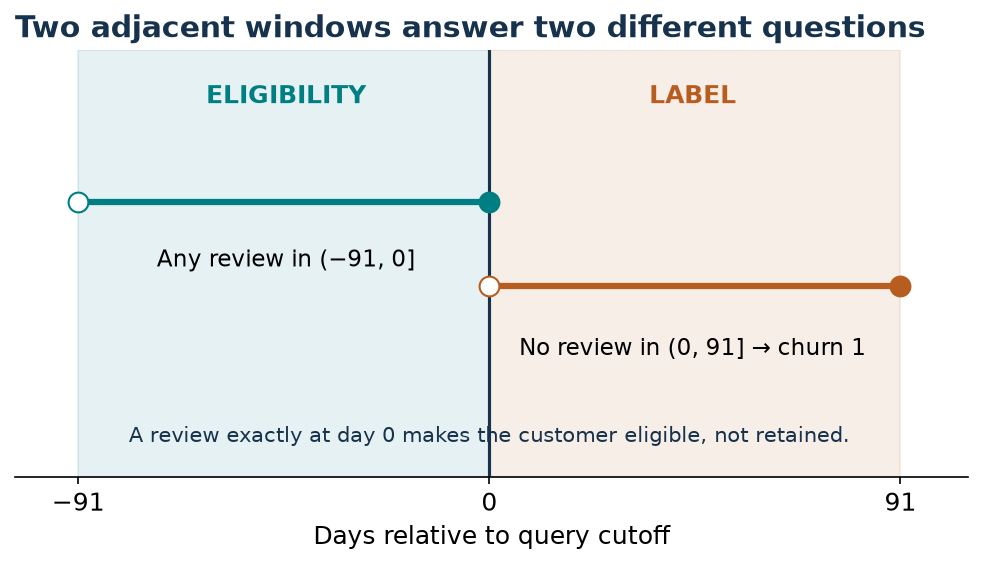<figcaption>Source-exact endpoint contract: recent (−91,0], future (0,91]. Open circles exclude endpoints; filled circles include them.</figcaption></figure>

**Predict before changing the control:** with a fixed review on day −12, does moving the next review from day +91 to day +92 change eligibility, the label, or both?

Baseline: day+91 gives churn 0; day+92 gives churn 1. Eligibility stays true.

Implement this contract in the live TODO below.

**Lab task 1:** implement the two windows. Return `(False, None)` for an ineligible customer. CHECK tests exact endpoints, duplicated events, missing values and a different horizon. A customer outside the population is not a negative training example.

A **mature label** is one whose entire future window has elapsed. At cutoff t, the model may use earlier features, but the target cannot be finalized until t + H. Never infer a churn label merely because a data extract stopped early. The benchmark supplies fixed temporal task tables; the audit below reconstructs their labels from the downloaded event archive.

> **Scope check.** These timestamps record review events. They do not certify when every field first became available to a production system. Product metadata without a timestamp is particularly important: a valid review cutoff alone does not prove historical metadata availability.



In [ ]:
# TODO
def review_target(review_days,cutoff,horizon=91):
    raise NotImplementedError("TODO: review_target")

In [ ]:
# CHECK
def check_target(fn):
    assert fn([-91],0)==(False,None)
    assert fn([0],0)==(True,1)
    assert fn([-1,91],0)==(True,0)
    assert fn([-1,92],0)==(True,1)
    assert fn([-92,1],0)==(False,None)
    assert fn([-90,-90,0],0)==(True,1)
    assert fn([0,1],0,1)==(True,0)
    for events,cut,h in [([np.nan],0,91),([1],np.inf,91),([1],0,0),([[1]],0,91)]:
        try:fn(events,cut,h)
        except ValueError:pass
        else:raise AssertionError('invalid target input accepted')
check_target(review_target)
print("PASS: review_target contract")

In [ ]:
# PROVIDED: checksum-pinned real queries; only IDs and relative event days.
raw=gzip.decompress(base64.b64decode('H4sIAAAAAAACA72d74oltxHFv/sphv3sDpJKf/0qIQSzrEMgsWE9NgTjd0+PYyZ7fpp75s6k42VZ0N571S11qepU1anqX756ePjw+Pnbv3//4ZuHP5+Dh4dffvv3/O+PP/34+MM/P30+P8nl/NPT1//96PGH7747P/hQUm5Hyuffh5S++e3vh+evffr50/ePPz7P/PSn1Pqn53keHo6xvhyWnOXT2mVY9NOcdFh1PGQ4Z5MrxTnX76O/PN/w47ef//bp8WnBz//1+dPHcxF//fjDT98/fdD0g4//evpy+n2qX7++vYOprDHrzR2sRyr37eARupIjhy67TxnPNN610vzSSuOelY45anl5pXE+tCPFfSud48uF1KKrdotKb1rU62vqa6xLxP+IEKnMMY3A1yE7kHtc9iSfLvTaqmdvs98Q2VNex90PMmRVOeEYh8pzL/Kky5BhD90/0R86Kkv2OvS6kZdufVbNVJpTPrqkowWG9ZXxvgPvkOZ44cGWO8R5nTvTrniwp7xCYddt+A6BLS8JbH19XWWOdlvzPB3TezWPnsrI7x6+ZSb9rhtdd83/8Xbfo4Jfktq4R2rnGLNdoYQrTr4djrl9ehFueJ7KWtO01i2ZfttZHWpblgxbkpO79CBP1aRLdeFSm1aTKOzaZDiW2LSpF8olq8krCurqlGEH1jl3S34eAWsxKsawxmprltrfpkgrphqmNtXKraXGWxdSZPuHGqNRZLgwddYr59r0UktVR9ctjSTLaH1ehirGHagit5Z7aTclut4v0R0WW3ctl5aM+jp3EeMOUeyYbsRl1uwefXdev8aNfSq/6bt23z6dh0gFdwFwKTAqwF8KqnLSE3nKOUDqDHXp9OJFpREXG6mZIW6ljenupGQFJ7gRLps/57XbcKiVvyZ8xMW3XRu52+mpn5tRJueWZ/fjknTTV2lGPHRUqJmcqCzdszz1Ps5FA264uXHTeaT5lg3uc7npznE2W7rJ1vbzfJ2XHXfggrZaM0r0DbAgLzjWOs6pq7ZYiLoAI+Y6N5t50b6s5zjLV79P9uHnb//hA1fRa6nrFmh8CkbcCxpPX1gX2uADFoVBp8MYqhIQtlGYdFqvDDc4X7Zz7Q6zHGOcSuiKneoIajDGUZv7ON4HR170KuZdgbmZZrli3XzeagiPohpoZN0GGMYjer3s+c+74nYncM/tio0I2JNQCA90imMwNl/iIsxVxuubEK3UfskhKEm1w1CbfIwSNvw0oA4qwlEcNxyyAmWUqKz85UZcqH3uOIY19TSu2Xh1bI8J+ao8ZuW6Y1buOGan/I8rTllR8JQHQm/MEkw9hPrtBfTaYOU55vdLAkjAx3pzfSGupHHa9n8zCPkOSZwnrkrXaICJPcIRhSOkbpKiMLUskYuJcjSF85gJcWzda3y3MVKQzXVGNreIiYuKX29mpqaBk+bPa3qTRbjDC885ouZrECR0ck1wSPVUaNzsmHldZgrbPYoqz9VrXHIS4EJAVNTR6ympMKjkwOy9UzmUd6LFGWPWfMWeTOS2t7Gipn1MBb726a4ya/ekXlo2GdI3bEyHCoKoZKNCnzwuDQlUlaRw31Z0zk/7rObLI+FpTHPXXMQrP05uyB83hmfqNrwoa17H5ow/fvrx0Xrjpy+e8g1Xq78lg1ORMp7KG9EcApLqy2W4kP8qAOUwpQEXLgNEI9l/YvzkpquK0SLUyuMoqLUo0JoFd6ZCdcCX0FBEQCD7wDLCHFHEAA9kNtTZz2rjmkYGqj5Hzlw0IJOH+7YmdjAzIhJNEwE98NQDnpvOfTRg4VIYGdavVy4LUQS9VSgP/po329NyJ2UbV1wdonFkiDSsMWbLMPw8T5WxRMhObU6W9jGCBxrDVdHTg1+h7RVzntZUg8ltuWXhmNeBTdBfa1qWIXT6QnDjQ4V+Qv+oNQhEmHJq9tny6dVBvQD/Jt0+cUXDwgNTFaAfXhpjNcZFk8LYX1jMrlm9QH5ZDUvTBzuQtNWTjEeVyQniQdWpVYvO6rLFFPxCNpJK3Mzuy4MMHhxwtTMBg9mRwuGRBZo/sj66mqzxwCYdPJccV0I8SrRm2RqkbkBfBM4aJtNAU0ZAD2K4/bwiS5+dHse9VCQjW+8OSUzkSafxxZtqGORnjzGcj1o2PkYzerNAVuDhZJiuDGEgpsnYBGQEN0ikypFHDBoJsf0FrXHbN9jmZb5sWcgJ49Fhp9TeAhxUEB70uQNs+SEIKUdRnx3YC3d52qFh7JAaiqyObMtWvRT3IKhSzZGAedFn1ruDFV2n6iucyUCyizKpIjzg3+qCIJIZ+cmGs9gqyXxEitWFfKcCw6kLWTR2wLw42iUBiUDLNJz01K1ppc3KuFyHuhygqeYRxtMCIRB6pDOIFxAHWiz1LVTJaBwU+hGf+iH0No4cSXbNiTvga7AKY4RzirH+oCIBiOwbU3oZN5d4AZS8Qzew9Goe5FDUjnQ/YGO1jit+O0GIZPZDNX4DFTAV44xSvEqzJrXi2QEfwR0/z5W61MAonI3eR7KWr9mIBG11cm5PXtY9q9CMZft8uhvF2cGz7gW6RLUFPuazLwP1C8NoHpLtO/gGjJw7ZyWrHE065mqUw1rhRkJHdk9jEKUZlYeTM2CSCkySWxJPu94Gv6zCCWM3lLIwS3PD5O6KC6yOhAZYwnwRNrYSWKokwm4Rp0z35deQuj4IGBDIOFwZXIkRQT0++DK2q2kGnLaBIAIglRiwUjVqoD0bL4mbuaqZeSCE1o2lpmaDCdt8jeaLF27XGb2UALiD6t3rKiNdEO9nkIIh1Ypn2+I6Nua4qz5wzTEvWGhZ0MNIdHCsYbQC3BwKLzE3Q3Bzn/oi2sW4I4E40opyhaxkqi5ZlpaPhIuqDNWvDIRpeBO1NSgUWbd/yavM6T6t7bIE3j1FyyPaFem6xSId2C2Xps1Ex4rSEcJGjkxdEwVTEwEOJIjoHJv6TTB5QeRBflbhYMuXFX62e/RUSW1coY9bcqAua+ENari6Oh29Ik6R1h9ajzRGXLIlC/HfvPkwSCMq9AfkREStQgDLYOINRTYk1TL+AjIJS53T1ivhS42qMlxcuoWxFA1KdfXrZoKHqI4X6u0KpqKT904G60vUoH4Pkfw8zKteYcEa/Gp13Gr6Q8sC6hir9CsOSBnZHhCwIdQYIxwf67qixTbuKVosc41L9ASd5eKGCC5Euaz4uNxD6krnIbvk2cOKI+jBaK8CBLhaZW16Nm6bXwYE0XtiBmu/NZIENC5rYHSr2VWQ1TFR16xHAXnKHqavxbm5QO4IvHWYY92ChbzA4kIweyB/zDFPNdgxmI4OfrdLIznF+uRbEDGYdcDjbTAhFA6sdHsMiMAvIzxFPQ9mMrc7TZo8xhlgDr64GymoS49wdw2a2dOdgL2CklwwM9QRGiipBckBrHasQgWFzACkGBXw5OGkKhC4XojAQ8Ankp16ZRA5CntUsZqS0X7jZ6y6Pbh3+A79JTLnHa5DKmNdYgsmcYAvQN15ADW5PAL21zGzCkA2eESqlDt8nAxlYFPvCAigkhmhBD2QA86THjBCRehmpmWZ+CRlAtQQKDyQP1R9YkPAgUO+rPnyIbAOM50ImEuMmV0GlTsqOEfJ0GGK2hSajIHkRiYnrnd3Kwc+XgzJJVeJnx0ACVTR0GoDZmbHVUNbvjyRjYM3ueXbAul15I+bu/aWsmTuLptjSL5pRjOfual2sJ0aORFQTb3a7DbHUG1sX4OOhWgJQfplsLCLeGQVk56dKPyam5Mpl4YeUVSA/jPUE6w1zYNpChsZORBDQN0jKH54wpmM5MxNI6EWqmV5vjRSkjRuQE8zDYswgc0O1u7VoPrAeJKhC/rwJs/T9iSoUEggB56Hs2J9rqVBpnVi4z8ch9jSV7h6vFK0GiyhAqlbD6Mrp+3gAAHqg8WKcgrwRCHd7FKUVYJmdhR5KDQ2nVnLZEBhIQBDxgSgcegHXLIMj0OlMjooPdOobFQUgMKDYdTq8sG6hGAzIU3/6l2hcw2GAGVdn8JY4Bbop43VJaYqGFC4miAulDDatGRV/1sftGIw0CmD3dYohDeSJZECBq0B3nXGWIMADJjNVyz0oC0ylejsJ6V4F8EIUBGS4+rBDSmIr3eTXYLJaCCyqqmsii+jFqOJwNqtXggmW30SFIK4h1iN0pjL7daqqNNp7qYA/OG+dMT2tvZv5vjQU0TuoYWpKZmuGw4mjmQJwfAAQA8DdWbaC6GFoJrSHt3qZBVBkneLE4QjM8gG1iAAPds+s08JPCg6ZNuYp3YrKrSOaWf3kBb2dibJsvAPKzzbWNY/ZCE9/ZkgY3jau2GaME9WLiZ7ubz1GHHBl4MM9cUSdhP3ODJDBlsHEu/KTXbfKLbQDkYIicqGyXgx0nBLop/YbjM1yZ1nU/wJwEgO8OzQ1KlZp3TiKY/1SskoFrftNMdbemLa9czN0vB+6bLhhDPFk6zHhn6Vx8DtBzUI8HvHiwVYk0ofn2AqTV+rkOmQQkPA2d6Ww7ciDB9Lq4ytZZaR0Ola0P7ABbxfOn3JkpgPkAAOFGcfQEvn5wgnDe435iPapMbeyrXDWgSGNhky4u9B999dbOa82Ohr+P3ePifHn+UbGiIAiiuGAxcMLtdwtHA8F1ZLoj7LYzXlzCFE7sveBoLB1WCZyvcLuBXB3YRcw75Aqksmz5fvKuhWKAofOnnDsWx9OzaF/YGzwaS21wnjRQAUXCZLprvlEaorpytUFxMRCDhNTAcGS5gYMtw4u9l/H6iLZfl4T8UpgzxHrBhl62ALCs9xt/PRf0fmdQvbBe+PpBWGXFlXjc+ZTqBPtM3X2ivz2fKf7G+ezTwIkdk2aGtsgO/DHLPxQdlOMltkDJu5KVDvmeX9DNGirplF0MWTXNgCF7F5TsdMLmuBNujlYTQDGHblnHxzZjbnprjY9j69/TyorFj520gf0sBfuT0i4Ya00+nHpJpsXY2RP/E1+Ugg0ANEgQr9x2SpRODRo/8IcBIKXk0Gia1Ti+XGAuT0at8dYtvdMMuKSEa4YR2mSp5lINNEmNGsN0NqFeCZLc23yyHKNHMqWy+58kc97ChS1oj77RFaTU4zzayGkU1Cg25Gu70qOBgd2NWM6m0ykI4UwGh+Ha9fcX1CFFcsE4lcpjmejtimvxbXv+j2FeE2g5eBpDD5XiiFnaiMNXvJoDF8GpsYQcEhfsu3jeC9OOA18N0U1bxqBoKbyXJCCL0bRwSZTeb5El1ZfBx4O4QqCbQ0QlTFEgnB2SmuKg6ICV3kSnU9WYGHOJVm9gp4ybgN0Lwwsybm0VcnNGKHMC4oDaCFbMNhpBD5f7adGji8uht8RrAJzbXwmm4JgT5N5IdX44Fyvctxy9lnGaeuh7ur4nQOUkTIqARa1eHLaAaNygg2sVquiSR+i65jGb1rVDb0cSMHDic6QHfHVOg2MF2RECoA8RSq5V5UfYKV9eNKH1A0wJ6R6GaBFRG6sqQBV8JrP6thVyH3AMY8wnnbsLkL4eVqablm4IH3xyWjONBhA11qW6DIXyN0eoCbPgYEzlAjhtQkIilNgWlD5x58uWbXI7S7/pGICfOe6UOEz1DC48fruHozpXuNBIAw7TUgWQirojUiX55WXaE1LAV6IrUECh36qblMNbIfaAFRw9EWGbnfuk5VExkfoAAUh1ZrXobhEWh7C5GGG4RuGkjrqx3FddnnFzYZIAuJDJQ9APuAZoMifCZX0QIVmEtVSWNhLOkEcdtLBIyY7kQXtinRJxaG2EiHgj1/HHZHs2qCRjWFy/0Ul4VtJzobzfhPeGcKwDiaccC2sSc72D1lmHuu7h4P1GdUu62oS6IkmC5YEFbUtnOXFW/MBoSs7jbJI0gFdrLym081ZvtalY3twenLFuqrLvIFkArNC4YUssQzLRMcBdBEQj/C9y0J9jlkDQwzjSwOQwNKNnBwnFLk2VCEhvotFnss13Nqol0TbLMefWAkuDGbUHZXqTOnEQLnZyOe3kE/IyFmOo4K2v6xIgwcBiTA9Cl0ZqmbbXgOzvng26Swl3hDdnb97CubfXZDx87DxGEQR2dv1mXO6Zb7jNsYh4TCZBwAJE0RoUHp//aK2Gli7MjY4+UxKAOF57xcX0YATRBd4CtBLoD/EaBBwzgkyaZhM4EfiPrFDgyOZnJon4G08vZGOAC6SdqmIzjj7TV8azeTnNX1sc2ORQLvd3spZw3X8Bs6FixkpuD0t51x+2pOQxR7X3k4XMAUHvxhNI5HhKNPE2bL2WlhOouqzzthXhhXsjOz200FJrxlQNHhYnCMJKjC7XzH/TTKGtEP2F9U8LLiYzgYAM8CqhFDBM17dcRT1CfiFILQT3UHtar+Dt6t3fTxNtvvG2APDD28dhuhgY6HspwMMo6gYoXiThD1sLH4LR5o130eeJMrPoWSbsDJLmi+XdfVCoH6iTdcQ/2DB4p2U+gzxxUhSdmTAfNs0pqcEM46DWAC0xdToU0SjmQFC1qPxlThX+s2YGRGCDEVPKJJ/g2AQSb3GTiYxYDIBLj8A7iZeZhHuHXtJmkN6Qo4kss54ltT+1ptnfIkA7ZNRystGyEXJZDw5pLJQ7DahORpurjISTqTv7HswsVaYW0quAbwnvmsYGw51sDdRLQNla14dQy6CMDXBhaZfAUBksnTpSqKPUgkTSLWgWQ6APfBfAvCd6xQYj0eiraJSLUTsM69kn29R6M8qhlauoGLzfPBZMy+uQd4nWCWz3G7beV0+Ujyp4JtlboxPP8peX9HG5v5Uiu3+PKdhF/9+m8zd53Y3pIAAA=='))
assert hashlib.sha256(raw).hexdigest()=='b9e27962dff0fc6e6e64395e1a32350cc99d97e69da8d204d960d02bca5d972f'
SAMPLES=json.loads(raw)
for split,rows in SAMPLES.items():
    for row in rows:
        assert review_target(row['events'],0)==(True,row['target'])
print('PASS: 36 real queries independently reconstructed with YOUR function')


## 3 · Model architecture: how a book reaches a customer score

The database has **customer**, **review** and **product** tables. A primary key uniquely identifies a row. A foreign key points to a row in another table. Each review links one customer and one product. The raw archive has 20,862,040 reviews for reconstructing labels. The released model snapshot at 2016-01-01 contains 12,644,508 reviews, 1,850,193 customers and 506,012 products. The relational graph makes each row a node and each key relationship an edge, with reverse edges so information can travel in both directions. Keys construct links; they are removed from ordinary feature columns. [Released graph constructor](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/modeling/graph.py)

The architecture is the basic RDL model already studied in Lesson 131, applied to this domain. It does not introduce a new neural architecture.

<figure class="stream-figure" tabindex="0">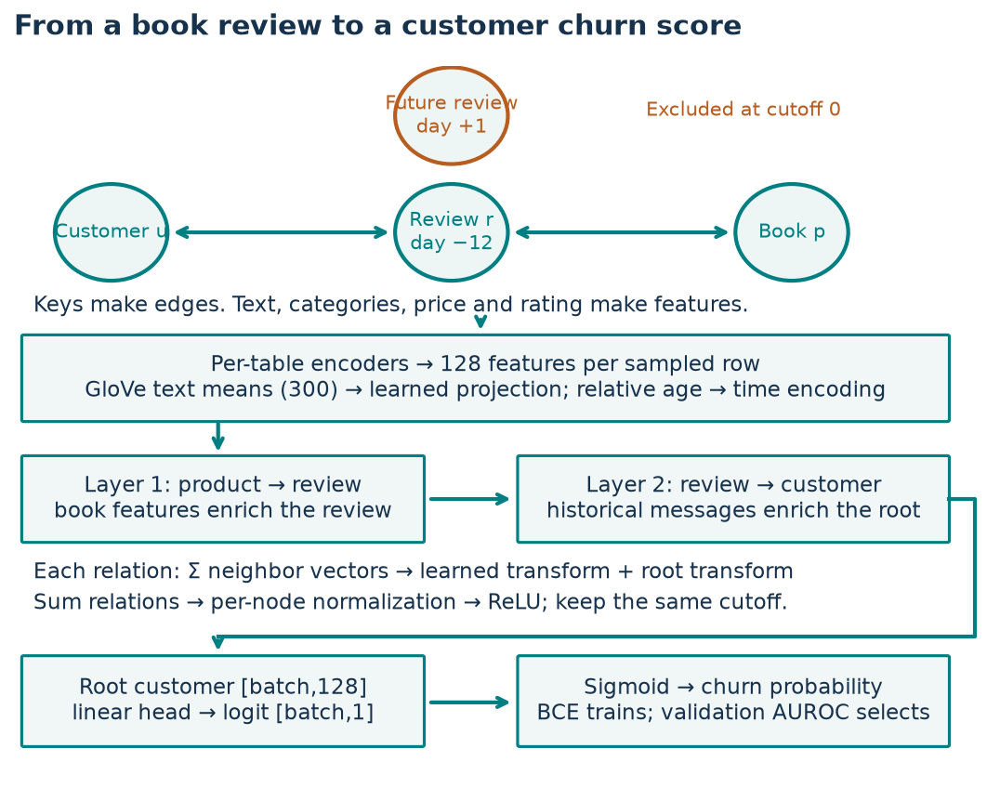<figcaption>Basic RDL on customer, review and product rows. The highlighted two-hop path carries historical book information into the customer root.</figcaption></figure>

**First, encode rows.** Each table has its own encoder. Numerical columns such as price and rating, categorical columns and text columns are converted into learned vectors. Released text preprocessing averages pretrained GloVe word embeddings into 300-dimensional vectors. PyTorch Frame's table encoder combines columns into a 128-dimensional vector per row. In this archive, customer names are text features; product features include category, brand, title, description and price. Reviews supply time, rating, verified status, review text and summary. Names are model inputs here, so the basic model is not a featureless customer-ID lookup. [Model](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/examples/model.py) · [Text preprocessing](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/examples/text_embedder.py)

**Next, express age.** For each timestamped sampled row, subtract its event time from its owning query's cutoff. Convert seconds into days, encode that age and add the resulting vector to the row representation. Different customer queries may share a review yet give it a different age.

**Then, pass messages twice.** For each relationship type, the released model sums neighboring vectors, applies a learned transformation and adds a transformation of the receiving node's own vector. It sums outputs across relationship types, normalizes each node's vector and applies ReLU, which replaces negative coordinates with zero. At the first layer a review can receive product information. At the second layer the customer can receive that enriched review representation.

> **In plain terms.** A book influences the customer's prediction through a historical review. The model does not need a manually written column named “recent books of this type.”

**Check the reach.** Can two layers directly bring in another customer's vector through a shared book? The path customer → review → product → other review → other customer has four edges. Two layers can bring in the book's features, but not that other customer's vector along this path.

**Finally, score the root.** The root is the customer about whom the query asks. A linear head converts its 128 features into one **logit**, an unrestricted real score. The **sigmoid**, 1/(1 + exp(−logit)), converts that score into a number between zero and one. Binary cross-entropy penalizes confident wrong predictions during training. Validation AUROC selects the checkpoint; test labels do not select it. A sigmoid output is not automatically calibrated to real-world probabilities.



## 4 · One cutoff follows the entire path

A **receptive field** is the set of nodes that can influence the root after the chosen number of message-passing layers. It depends on graph links, time filtering and neighbor sampling. The released two-layer runner samples up to 128 then 64 neighbors per relation, using temporal uniform sampling. This limits work, so the sampled field may be smaller than the entire available historical field.

**Worked example.** Customer u links to review r0 at day 0 and review r1 at day +1. Each review links to its book. At cutoff 0, r0 and its book can influence u through two hops; r1 and its book cannot enter through that future review. Moving to the second hop does not move the cutoff into the future.

At cutoff0, only r0 and book0 enter. At cutoff1, r1 and book1 also enter.

Implement this contract in the live TODO below.

**Lab task 2:** return reachable nodes while preserving the original cutoff at every hop. This small deterministic function explains availability; it is not a replacement for the released stochastic sampler. The source permits events at the cutoff (`≤ t`), matching the recent-window endpoint here. Strictly earlier (`< t`) would be a different protocol at equal timestamps.

**What remains unproven?** Untimestamped product attributes can still contain later information. The released preprocessing also computes column statistics on the supplied database snapshot, rather than fitting every statistic only on training queries. Preserve and disclose these source choices when replaying the paper; changing them defines a separate experiment.



In [ ]:
# TODO
def visible_paths(edges,node_times,root,cutoff,hops=2):
    raise NotImplementedError("TODO: visible_paths")

In [ ]:
# CHECK
def check_paths(fn):
    edges=[('u','r0'),('r0','p'),('u','r1'),('r1','p2'),('p','r2')]
    times={'u':None,'r0':0,'p':None,'r1':1,'p2':None,'r2':2}
    assert fn(edges,times,'u',0,2)==['p','r0','u']
    assert fn(edges,times,'u',0,4)==['p','r0','u']
    assert fn(edges,times,'u',1,2)==['p','p2','r0','r1','u']
    assert fn(edges,times,'u',0,0)==['u']
    try:fn(edges,times,'r1',0,2)
    except ValueError:pass
    else:raise AssertionError('future root accepted')
check_paths(visible_paths)
print("PASS: visible_paths contract")

## 5 · Reconstruct a domain baseline before trusting a complex score

A **recency baseline** assigns each eligible customer the number of days since their last recorded review. Larger values predict more chance of review absence. It has no fitted weights or tuned threshold. This is a course experiment, declared independently of the paper model.

The full audit reads only review customer IDs and timestamps. It sorts events by customer and time. For each query, it counts events in each window by subtracting two sorted-array insertion positions. Every stored label is checked against the independently reconstructed future count; every query must satisfy recent eligibility. The learner notebook then rechecks real query examples using task 1.

| Split | Queries | Churn prevalence | Recency AUROC | Recency AP |
|---|---:|---:|---:|---:|
| train | 4,708,383 | 0.6240 | 0.5997 | 0.6917 |
| val | 409,792 | 0.6420 | 0.5987 | 0.7072 |
| test | 351,885 | 0.6064 | 0.5823 | 0.6628 |

**Measured:** all **5,470,060** labels reconstructed with zero mismatches and zero ineligible queries. Both database and task archive hashes match the pinned release. The full raw archive contains 20,862,040 reviews, including later events needed for label reconstruction. The model snapshot excludes reviews after its test cutoff.

**Held fixed:** official query identities and labels, a 91-day horizon, and one fixed recency score. **Measured:** AUROC and average precision on the supplied splits. This does not isolate a GNN architectural advantage. It establishes a transparent domain baseline and checks that the experiment asks the intended question.



## 6 · Read a ranking metric without inventing a business result

**AUROC** measures how often a randomly chosen churn-positive query receives a higher score than a randomly chosen non-churn query. A tied score earns half credit. One means every such pair is ordered correctly; 0.5 is the random-order reference. It does not choose a contact threshold, price a campaign or estimate incremental retention.

**Worked example.** Non-churn scores are [0, 1]; churn scores are [1, 2]. Three comparisons are wins and one is a tie. AUROC is (3 + 0.5)/4 = 0.875.

<figure class="stream-figure" tabindex="0">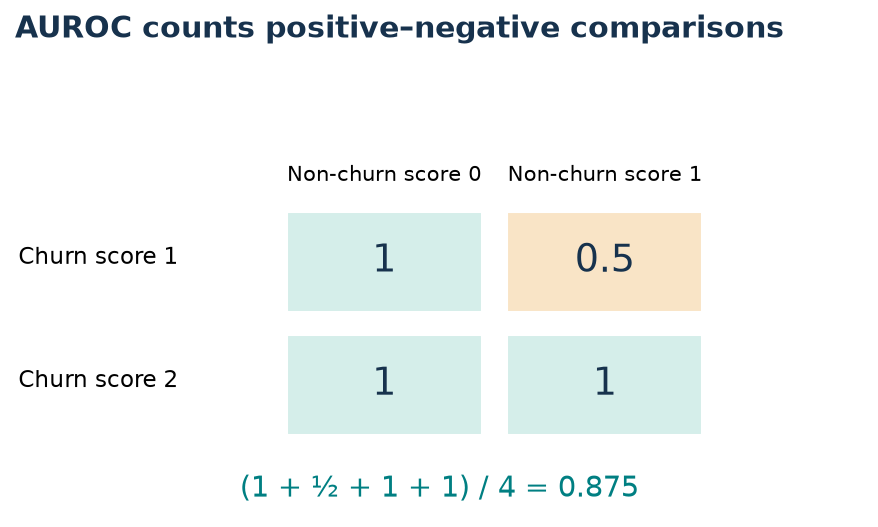<figcaption>Synthetic scores: three wins and one tie yield AUROC 0.875. This is arithmetic, not a measured model score.</figcaption></figure>

Implement this contract in the live TODO below.

**Lab task 3:** compute AUROC by score groups, preserving half credit for ties. CHECK compares your result against a separate pairwise enumeration and rejects single-class inputs. The notebook also compares your implementation with the archived full validation and test recency predictions.

**Average precision (AP)** averages precision at recall increases as a threshold moves through ranked predictions. **Precision** is the fraction of selected queries that really have label 1. **Recall** is the fraction of all label-1 queries selected. AP's scale depends strongly on positive prevalence; AUROC and AP answer different questions. A very common churn label can yield a high AP even when ordering is only moderately useful. [Metric definitions](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)

**Put AP beside a no-ranking baseline.** Assign the same score to every query. There is one tied score group: admitting it gives recall 1 and precision equal to the positive fraction. Thus AP equals prevalence, while AUROC is 0.5 because every positive–negative pair ties. On the actual saved task labels:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:.4em .25em"><thead><tr><th>Split</th><th>Churn-positive / queries</th><th>Constant-score AP</th></tr></thead><tbody><tr><td>Validation</td><td>263,098 / 409,792</td><td>0.6420</td></tr><tr><td>Test</td><td>213,400 / 351,885</td><td>0.6064</td></tr></tbody></table>

Both constant-score AUROCs are **0.5**. The AP difference comes entirely from the label proportions; neither split received a useful ordering. This baseline uses no fit and no score tuning. It makes the actual recency AP easier to interpret alongside AUROC and prevalence. [Saved query labels and recency predictions](https://avistian.github.io/relational/labs/evidence/l138/recency_predictions.npz).

**Transfer check.** Change the common score from 0 to 100. All ties remain, so both ranking metrics remain unchanged. Explain why the score magnitude cannot supply a contact policy or a calibrated probability, and why comparing AP between these two splits needs the prevalence context.

A practical next experiment would choose a contact budget using validation, freeze the policy, and measure a suitable outcome on a later period. An actual retention claim additionally needs evidence about the intervention's effect, not just an observational review-absence model.



In [ ]:
# TODO
def rank_auc(target,scores):
    raise NotImplementedError("TODO: rank_auc")

In [ ]:
# CHECK
def check_auc(fn):
    assert fn([0,1],[.5,.5])==.5
    assert fn([0,0,1,1],[0,1,1,2])==.875
    assert fn([0,1],[0,1])==1
    assert fn([0,1],[1,0])==0
    rng=np.random.default_rng(138)
    for _ in range(30):
        y=np.r_[0,1,rng.integers(0,2,28)];s=rng.integers(0,5,30)
        brute=np.mean([float(a>b)+.5*float(a==b) for a in s[y==1] for b in s[y==0]])
        assert abs(fn(y,s)-brute)<1e-12
    for y,s in [([1,1],[0,1]),([0,1],[1]),([0,1],[0,np.nan]),([0,2],[0,1])]:
        try:fn(y,s)
        except ValueError:pass
        else:raise AssertionError('invalid score input accepted')
check_auc(rank_auc)
print("PASS: rank_auc contract")

In [ ]:
# PROVIDED: all held-out recency predictions; no retraining implied.
raw=base64.b64decode('...')
assert hashlib.sha256(raw).hexdigest()=='4f0e98e4cee71cb9a373420b368ea1936917b34393e9ad8be3aa86882c804d97'
SCORES=np.load(io.BytesIO(raw));EXPECTED={'val': 0.5986550614751239, 'test': 0.5822758771711511}
score_rows=[]
for split in ['val','test']:
    value=rank_auc(SCORES[split+'_target'],SCORES[split+'_score'])
    assert abs(value-EXPECTED[split])<1e-12
    score_rows.append(dict(split=split,queries=len(SCORES[split+'_target']),auc=value))
display(pd.DataFrame(score_rows))


## 7 · Full reproduction: target, execution and remaining gap

The named target is **RelBench v1 Table 6, rel-amazon/user-churn, basic RDL**: five runs, validation **70.45 ± 0.06** and test **70.42 ± 0.05** AUROC percentage points. An AUROC of 0.7042 is 70.42%. Those ± values describe run-to-run standard deviations. [Published table](https://arxiv.org/html/2407.20060v1#S5.T6)

> **Scope check.** The pinned released archive has **4,708,383 training queries**; the paper's Table 2 lists **4,732,555**, a difference of 24,172. Its validation/test row counts and positive counts agree with the released tables. A matching release checksum therefore does not prove identity with the paper's original training table. We report a complete released-pipeline replay separately from exact historical reproduction. [Count audit](https://avistian.github.io/relational/labs/evidence/l138/paper_alignment.json)

**Neural reproduction status: RELEASED_REPLAY_COMPLETE.** All five full-data runs completed ten released-protocol epochs. Validation and test scores are descriptively CLOSE to the named paper targets. The checksum-matched released archive has 24,172 fewer training rows than the paper; exact historical reproduction remains unestablished.

Full five-run training: **COMPLETE**. Historical run identity: **NOT_ESTABLISHED**. See the [execution ledger](https://avistian.github.io/relational/labs/evidence/l138/reproduction.json) and [budget](https://avistian.github.io/relational/labs/_budget_l138.json).

| Split | Fresh AUROC % ± sample SD | Paper AUROC % ± reported SD | Descriptive verdict |
|---|---:|---:|---|
| val | 70.4653 ± 0.0566 | 70.45 ± 0.06 | CLOSE |
| test | 70.3711 ± 0.1234 | 70.42 ± 0.05 | CLOSE |

All five seeds completed ten source-defined epochs. All 3,808,385 held-out predictions were aligned to audited query identities and independently rescored. The predeclared 1.0 percentage-point tolerance is descriptive, not an equivalence test. Historical training identity and whole-paper reproduction remain unestablished.

The full runner retains text encoding, the complete database and task tables, two 128-channel graph layers, sum aggregation, batch size 512, Adam learning rate 0.005, ten epochs and validation-only selection. The released stopping condition allows 2,001 training batches per epoch when enough batches exist. Here an “epoch” is this capped pass, not a complete pass through all 4.71 million training queries. The five declared seeds are 0–4; exact historical seed identities are not established. The notebook contains the model, graph constructor and trainer visibly, and a gated full execution path.

**Do the checks answer the claim?** A successful label audit checks the task. A notebook pass checks the portable learner code. A timed embedding sample estimates one preparation cost. Only completed, aligned full training runs can support the named model-score reproduction. Keep these conclusions separate.



### CHECK · all measured neural predictions

The author audit checked entity/cutoff alignment for every seed. This compressed packet preserves that ordering; your live metric now reconstructs all ten held-out scores. The data-transport cell is collapsed; the scoring code stays visible.

In [ ]:
# PROVIDED: compressed complete neural prediction vectors. Expand only to inspect the data transport.
NEURAL_RAW=base64.b64decode('...')
assert hashlib.sha256(NEURAL_RAW).hexdigest()=='cf9bdc28f21adafcf900b4598cc50173299d18cf9947bcd9e046531004e95461'

In [ ]:
NEURAL_EXPECTED={'val': 0.7046526570570071, 'test': 0.7037111926765133}
# CHECK: source audit aligned entity/cutoff keys before packaging.
# This cell re-scores the preserved ordering using YOUR rank_auc implementation.
NEURAL=np.load(io.BytesIO(NEURAL_RAW));neural_rows=[]
for split in ['val','test']:
    values=[]
    for seed in range(5):
        pred=NEURAL[f'{split}_{seed}'];y=SCORES[split+'_target']
        assert len(pred)==len(y)
        value=rank_auc(y,pred);values.append(value)
        neural_rows.append(dict(split=split,seed=seed,auc=value))
    assert abs(float(np.mean(values))-NEURAL_EXPECTED[split])<1e-12
display(pd.DataFrame(neural_rows))
print('PASS: all 3,808,385 archived neural predictions re-scored; no fresh training implied')


## 8 · Exit: defend one query and one claim

Without reopening the explanation, write a short defense containing:

1. One real query's recent window, future window, eligibility and label.
2. A two-hop product-to-customer path and why a future review cannot enter it.
3. The meaning of one measured recency AUROC, including tie handling.
4. The strongest reproduction claim supported by the evidence, and one missing piece.
5. Why this target does not establish purchasing churn or a campaign's causal effect.

Write your defense, then ask the teacher to evaluate it.

Run the live CHECK cells and paste your exit defense into chat. Ask follow-up questions about any unclear step; successful reference execution does not establish your mastery. At your next session, reconstruct the two windows from memory before looking at the figure.


<!-- sequence-next:start -->
**Carry this forward.** Carry the population check into the trial task: an absent future observation can mean no query, rather than label zero. [Continue to Lesson 139](https://avistian.github.io/relational/lessons/0139-healthcare-trial.html).
<!-- sequence-next:end -->


## PROVIDED · complete visible released model and graph construction

This code uses PyTorch Frame column encoders and PyG graph primitives. The synthetic fixture below executes the complete forward/backward path, separately from the full-data experiment.

In [ ]:
# The MIT License (MIT)
# 
# Copyright (c) 2023 RelBench Team
# 
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
# 
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
# 
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN
# THE SOFTWARE.

from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

# %% Relational node predictor (PROVIDED)
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])


# %% Full database to REG and query transform (PROVIDED)
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )




In [ ]:
"""Small complete RDL forward/backward, separate from Amazon training."""
import copy
import pandas as pd
import torch
from torch_frame import stype
from torch_frame.data import Dataset
from torch_geometric.data import HeteroData

def neural_fixture(Model):
    torch.set_num_threads(1);torch.manual_seed(138)
    data=HeteroData();stats={}
    for kind,values in [('customer',[1.,2.,3.,4.]),('review',[3.,5.,9.,10.]),('product',[2.,7.,11.,16.])]:
        frame=Dataset(pd.DataFrame({'x':values}),col_to_stype={'x':stype.numerical}).materialize()
        data[kind].tf=frame.tensor_frame;stats[kind]=frame.col_stats
        data[kind].batch=torch.tensor([0,1,0,1]);data[kind].n_id=torch.arange(4);data[kind].num_sampled_nodes=[2,1,1]
    data['customer'].seed_time=torch.tensor([864000,1728000]);data['review'].time=torch.tensor([777600,1555200,691200,1468800])
    for src,dst in [('review','customer'),('review','product')]:
        edge=torch.tensor([[0,1,2,3],[0,1,0,1]])
        data[src,'to',dst].edge_index=edge;data[dst,'rev_to',src].edge_index=edge.flip(0)
    for kind in data.edge_types:data[kind].num_sampled_edges=[2,2]
    model=Model(data,stats,2,128,1,'sum','batch_norm');model.train()
    logits=model(data,'customer').view(-1);assert logits.shape==(2,)
    loss=torch.nn.functional.binary_cross_entropy_with_logits(logits,torch.tensor([0.,1.]));loss.backward()
    for name,part in [('encoder',model.encoder),('gnn',model.gnn),('head',model.head)]:
        gradients=[p.grad for p in part.parameters() if p.grad is not None]
        assert gradients and all(torch.isfinite(g).all() for g in gradients)
        assert sum(float(g.square().sum()) for g in gradients)>0,name
    return dict(status='PASS',logits=logits.detach().tolist(),loss=float(loss.detach()),scope='Synthetic full-stack forward/backward; not Amazon model training'),data,stats,model


FIXTURE,_,_,_=neural_fixture(Model)
print(FIXTURE)

## NEXT STEP · complete source trainer

The full runner includes text embeddings, archive checks, sampling, optimization, validation selection and keyed prediction artifacts. It is not executed by the default notebook. Large host memory is needed; respect the reproduction budget. [Pinned environment](https://avistian.github.io/relational/labs/requirements-l117-runtime.txt).

In [ ]:
"""Complete released RDL classification lane. Full data/text; no teaching caps.

Requires requirements-l117-runtime.txt plus torch2.5.1 and matching pyg-lib.
Preprocessing and model source are visible in the companion notebook.
"""
import copy,hashlib,json,time
from pathlib import Path
import numpy as np
import torch
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything
from torch_frame.config import TextEmbedderConfig
from relbench.datasets import get_dataset
from relbench.tasks import get_task
from relbench.base import Table
from relbench.modeling.utils import get_stype_proposal

def full_run(output,seed=0,epochs=10,cache='/evidence/full-cache',prepared_root=None):
    from sentence_transformers import SentenceTransformer
    start=time.perf_counter();torch.set_num_threads(1);seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=False)
    device='cuda' if torch.cuda.is_available() else 'cpu'
    dataset=get_dataset('rel-amazon',download=prepared_root is None);task=get_task('rel-amazon','user-churn',download=prepared_root is None)
    if prepared_root is not None:
        prepared_root=Path(prepared_root)
        dataset.cache_dir=str(prepared_root/'unpacked');task.cache_dir=str(prepared_root/'unpacked/user-churn')
    manifest={}
    for name,expected in [('db.zip','db71c7701b892a4eb7481ff04d14d25465795501dba3a5931aabee9930805efe'),('tasks/user-churn.zip','cddd511a1f609aea286cf2e20803f489ab9b3158e18cea66e0888d174b1515f0')]:
        h=hashlib.sha256()
        archive=(prepared_root/'cache'/name) if prepared_root is not None else (Path(dataset.cache_dir)/name)
        with archive.open('rb') as f:
            while chunk:=f.read(8*1024*1024):h.update(chunk)
        manifest[name]=dict(sha256=h.hexdigest(),historical=expected,match=h.hexdigest()==expected)
    (output/'data_identity.json').write_text(json.dumps(manifest,indent=2))
    if not all(v['match'] for v in manifest.values()):raise RuntimeError('Archive differs from pinned release; audit a separate replay explicitly')
    if prepared_root is not None:
        data,stats=torch.load(prepared_root/'graph.pt',weights_only=False)
    else:
        db=dataset.get_db();types=get_stype_proposal(db)
        text=SentenceTransformer('sentence-transformers/average_word_embeddings_glove.6B.300d',revision='e5e8fec6971be8960cfaa853a77a6ddc62a265d7',device=device)
        def embed(strings):return torch.from_numpy(text.encode(strings,show_progress_bar=False))
        data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256),cache_dir=cache)
        del text,db
    if device=='cuda':torch.cuda.empty_cache()
    # Loading the cached graph makes raw review strings redundant. Read the
    # identical task parquet tables directly to avoid get_table's full-db load.
    tables={}
    for split in ['train','val','test']:
        if prepared_root is None:
            tables[split]=task.get_table(split,mask_input_cols=False)
        else:
            tables[split]=Table.load(prepared_root/'unpacked/user-churn'/f'{split}.parquet')
            ids=tables[split].df[task.entity_col].to_numpy()
            assert ((ids>=0)&(ids<data[task.entity_table].tf.num_rows)).all(), 'Dangling task identity'
    loaders={}
    for split in ['train','val','test']:
        table=tables[split]
        if split=='test':
            table=Table(df=table.df.drop(columns=[task.target_col]),fkey_col_to_pkey_table=table.fkey_col_to_pkey_table,pkey_col=table.pkey_col,time_col=table.time_col)
        q=get_node_train_table_input(table,task)
        loaders[split]=NeighborLoader(data,num_neighbors=[128,64],time_attr='time',input_nodes=q.nodes,input_time=q.time,transform=q.transform,batch_size=512,temporal_strategy='uniform',shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005);loss_fn=torch.nn.BCEWithLogitsLoss()
    audit=dict(query_occurrences=0,timestamped_node_occurrences=0,future_violations=0)
    train_targets=tables['train'].df[task.target_col].to_numpy()
    def audit_batch(batch,split):
        root=batch[task.entity_table];cutoffs=root.seed_time
        audit['query_occurrences']+=len(cutoffs)
        for kind,times in batch.time_dict.items():
            assert bool((times<=cutoffs[batch[kind].batch]).all()), 'Future event entered a query'
            audit['timestamped_node_occurrences']+=len(times)
        if split=='train':
            assert np.array_equal(root.y.numpy(),train_targets[root.input_id.numpy()]), 'Target/query misalignment'
    @torch.no_grad()
    def predict(split):
        model.eval();pred=[];ids=[]
        for batch in loaders[split]:
            audit_batch(batch,split)
            batch=batch.to(device);pred.append(model(batch,task.entity_table).view(-1).sigmoid().cpu());ids.append(batch[task.entity_table].input_id.cpu())
        ids=torch.cat(ids).numpy();assert np.array_equal(ids,np.arange(len(ids)))
        return torch.cat(pred).numpy()
    history=[];best=-float('inf');selected=None
    for epoch in range(1,epochs+1):
        model.train();total=0.;count=0;steps=0;clock=time.perf_counter()
        for batch in loaders['train']:
            audit_batch(batch,'train')
            batch=batch.to(device);optimizer.zero_grad();pred=model(batch,task.entity_table).view(-1)
            loss=loss_fn(pred.float(),batch[task.entity_table].y.float());assert bool(torch.isfinite(loss)), 'Nonfinite training loss';loss.backward();optimizer.step()
            total+=float(loss.detach())*len(pred);count+=len(pred);steps+=1
            # Preserve released off-by-one: 2001 batches, not silently corrected to2000.
            if steps>2000:break
        val=predict('val');metrics=task.evaluate(val,tables['val'])
        if metrics['roc_auc']>best:best=metrics['roc_auc'];selected=copy.deepcopy(model.state_dict());best_epoch=epoch
        history.append(dict(epoch=epoch,loss=total/count,queries=count,steps=steps,val=metrics,seconds=time.perf_counter()-clock))
        (output/'progress.json').write_text(json.dumps(history,indent=2));print(history[-1],flush=True)
    model.load_state_dict(selected);torch.save(selected,output/'selected.pt');scores={};saved={}
    for split in ['val','test']:
        p=predict(split);table=tables[split];scores[split]=task.evaluate(p,table)
        saved[split+'_pred']=p;saved[split+'_target']=table.df[task.target_col].to_numpy();saved[split+'_customer']=table.df[task.entity_col].to_numpy();saved[split+'_time']=table.df[task.time_col].astype('int64').to_numpy()
    np.savez_compressed(output/'predictions.npz',**saved)
    result=dict(seed=seed,epochs=epochs,best_epoch=best_epoch,selection_auc=best,history=history,scores=scores,temporal_audit=audit,seconds=time.perf_counter()-start,status='COMPLETE',historical_identity='NOT_ESTABLISHED')
    (output/'result.json').write_text(json.dumps(result,indent=2));return result



In [ ]:
# NEXT STEP: full source protocol. Check cost/memory before enabling.
# Local/Colab has no billing guard; Modal's operator enforces the aggregate cap.
if RUN_FULL_REPRODUCTION:
    import importlib.metadata as md
    required={'torch':'2.5.1','torch-geometric':'2.6.1','pytorch-frame':'0.2.3','relbench':'1.1.0','numpy':'1.26.4','pandas':'2.2.3','sentence-transformers':'3.3.1'}
    for name,version in required.items():assert md.version(name).split('+')[0]==version,(name,'use requirements-l117-runtime.txt and matching torch/pyg-lib')
    assert torch.cuda.is_available(),'A GPU and sufficient host memory are required'
    for seed in range(5):full_run(Path('l138-full')/f'seed-{seed}',seed=seed,epochs=10,cache='l138-materialized')
else:print('Full five-seed reproduction NOT_RUN in this default notebook')


In [ ]:
report=dict(status='PASS',real_query_examples=36,heldout_predictions=761677,neural_predictions=3808385 if 'NEURAL' in globals() else 0,neural_fixture=FIXTURE['status'],full_training='EXECUTED' if RUN_FULL_REPRODUCTION else 'NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')
Path('l138-report.json').write_text(json.dumps(report,indent=2));print(report)